In [ ]:
# SYNTHETIC DATASETS

Using torch device: cpu
Train shape: torch.Size([256, 1]) torch.Size([256, 1])
=== Training PQC-3 (Random Init) ===


/usr/local/lib/python3.12/dist-packages/pennylane/devices/device_api.py:193: PennyLaneDeprecationWarning: Setting shots on device is deprecated. Please use the `set_shots` transform on the respective QNode instead.
  warnings.warn(


[PQC-3 Rand] Epoch   1 | train_mse=0.50645 | test_mse=0.52084
[PQC-3 Rand] Epoch  10 | train_mse=0.37411 | test_mse=0.37298
[PQC-3 Rand] Epoch  20 | train_mse=0.25614 | test_mse=0.22637
[PQC-3 Rand] Epoch  30 | train_mse=0.23282 | test_mse=0.20156
[PQC-3 Rand] Epoch  40 | train_mse=0.23070 | test_mse=0.19846
[PQC-3 Rand] Epoch  50 | train_mse=0.23053 | test_mse=0.19816
[PQC-3 Rand] Epoch  60 | train_mse=0.23055 | test_mse=0.19862

=== Convex Initialization of PQC-3 (Algorithm-1 Stage-1) ===
[Convex Init] Epoch  1 | grad²/dim=1.355e-04
✅ Convex-init exit: gradient threshold reached.

=== Training PQC-3 (Convex-Init + Nonconvex Refinement) ===
[PQC-3 Alg1] Epoch   1 | train_mse=0.50722 | test_mse=0.51848 | lambda=0.490 | beta=0.099
[PQC-3 Alg1] Epoch  10 | train_mse=0.34615 | test_mse=0.33527 | lambda=0.409 | beta=0.090
[PQC-3 Alg1] Epoch  20 | train_mse=0.23129 | test_mse=0.22921 | lambda=0.334 | beta=0.082
[PQC-3 Alg1] Epoch  30 | train_mse=0.17961 | test_mse=0.18618 | lambda=0.273 | b

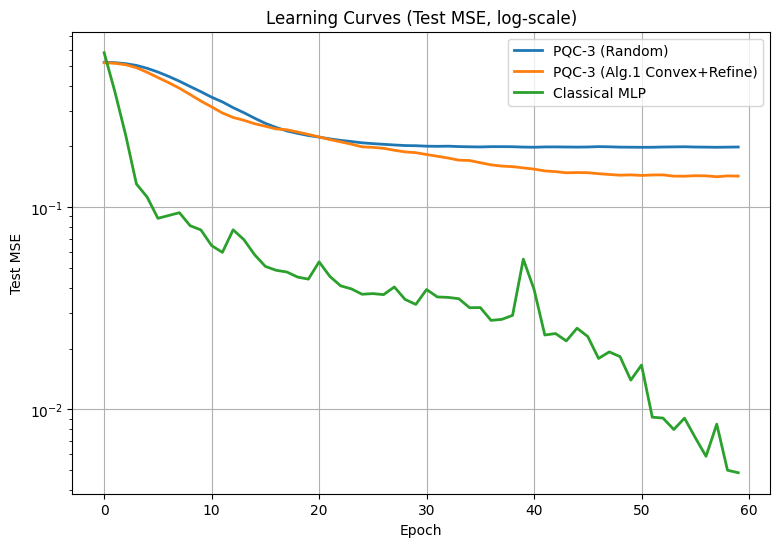

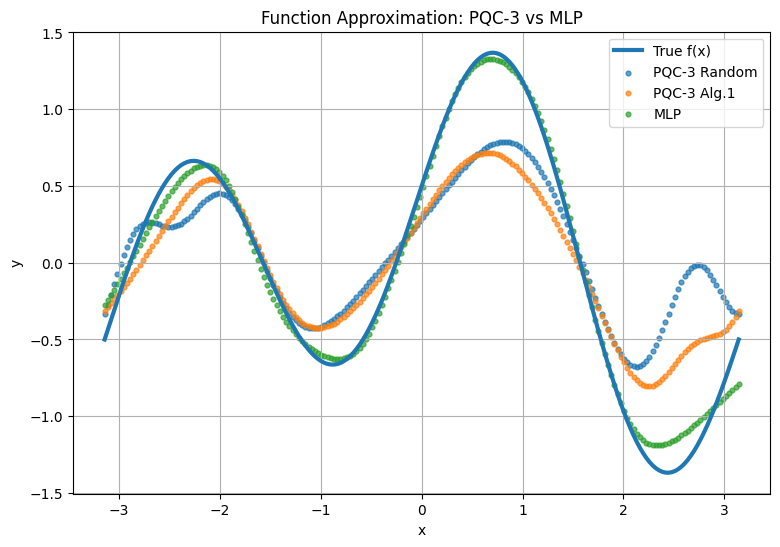

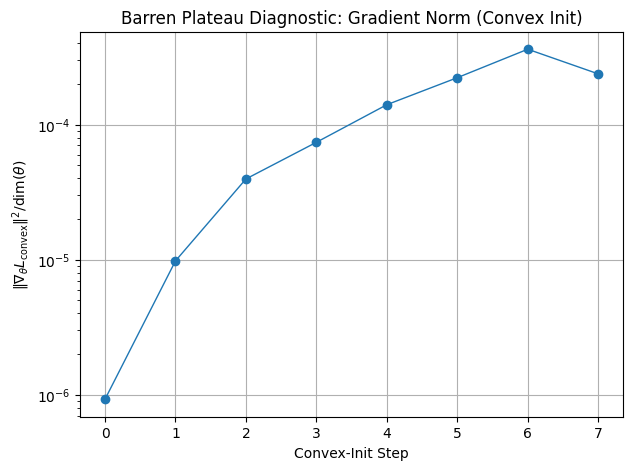


Figures saved to:
  - qml_outputs/learning_curves_pqc3.pdf
  - qml_outputs/function_fit_pqc3.pdf
  - qml_outputs/convex_init_grad_norm.pdf


In [ ]:
# ============================================================
# PQC-3 Random vs Convex-Initialized Benchmark
# (Algorithm 1: Two-Stage Optimization for Barren Plateaus)
# PennyLane + PyTorch
#
# Models:
#   - PQC-3 (Random initialization, standard regression)
#   - PQC-3 (Convex-initialized + Nonconvex refinement, Algorithm-1)
#   - Classical MLP baseline (He/Xavier)
#
# Extras:
#   - Learning curves (Test MSE)
#   - Shot-noise simulation (finite shots)
#   - Noisy channels (Depolarizing + Amplitude Damping)
#   - Barren plateau diagnostics (Convex-init gradient norm history)
#   - Hardware-compatible gates (IBM-style: RX, RZ, CNOT)
#   - Auto-generated CSV + LaTeX table and PDF plots
#
# Author: Boabang Francis (with ChatGPT scaffold)
# ============================================================

# 0. INSTALLS (uncomment in Colab)
# !pip install pennylane pennylane-lightning pennylane-qchem
# !pip install torch matplotlib pandas

import math
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import pandas as pd
import pennylane as qml
from pathlib import Path

# ------------------------------------------------------------
# Global setup
# ------------------------------------------------------------
np.random.seed(42)
torch.manual_seed(42)

device_torch = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using torch device:", device_torch)

# Directory for saving figures / tables
out_dir = Path("./qml_outputs")
out_dir.mkdir(exist_ok=True)

# ============================================================
# 1. Toy Dataset: Nonlinear Regression
#    y = sin(2x) + 0.5 cos(x)
# ============================================================

def make_regression_dataset(n_samples=256, x_range=(-math.pi, math.pi)):
    xs = np.random.uniform(x_range[0], x_range[1], size=(n_samples, 1))
    ys = np.sin(2 * xs) + 0.5 * np.cos(xs)   # nonlinear target
    xs = xs.astype(np.float32)
    ys = ys.astype(np.float32)
    return xs, ys

X_train, y_train = make_regression_dataset(256)
X_test,  y_test  = make_regression_dataset(128)

X_train_t = torch.from_numpy(X_train).to(device_torch)
y_train_t = torch.from_numpy(y_train).to(device_torch)
X_test_t  = torch.from_numpy(X_test).to(device_torch)
y_test_t  = torch.from_numpy(y_test).to(device_torch)

train_ds = TensorDataset(X_train_t, y_train_t)
test_ds  = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=64, shuffle=False)

print("Train shape:", X_train_t.shape, y_train_t.shape)

# ============================================================
# 2. Quantum Devices (Analytic, Shot-based, Noisy)
# ============================================================

N_QUBITS = 6

# Ideal analytic device (no noise, infinite shots)
dev_analytic = qml.device("default.qubit", wires=N_QUBITS, shots=None)

# Shot-based device (shot noise)
SHOTS = 1000
dev_shots = qml.device("default.qubit", wires=N_QUBITS, shots=SHOTS)

# Noisy mixed-state device for depolarizing + amplitude damping
dev_noisy = qml.device("default.mixed", wires=N_QUBITS)

# ============================================================
# 3. Classical-to-Quantum Feature Encoding
#    Map scalar x → R^4 and use AngleEmbedding.
# ============================================================

def encode_x_to_features(x_scalar, n_qubits=N_QUBITS):
    """
    Map scalar x to a feature vector R^{n_qubits}.
    Here: simple linear + trigonometric features.
    """
    x = x_scalar
    feats = [
        x,            # linear
        x**2,         # quadratic
        torch.sin(x), # nonlinear
        torch.cos(x)
    ]
    feats = feats[:n_qubits]
    return torch.stack(feats)

# ============================================================
# 4. Hardware-Compatible PQC Ansätze (IBM-style)
#    Gates: RX, RZ, CNOT (all native on IBM).
# ============================================================

def pqc3_ansatz(features, weights):
    """
    PQC-3 (deeper) ansatz.
    features: (n_qubits,)
    weights:  (n_layers, n_qubits, 2)
    """
    qml.AngleEmbedding(features, wires=range(N_QUBITS), rotation="Y")
    n_layers = weights.shape[0]

    for layer in range(n_layers):
        for i in range(N_QUBITS):
            qml.RX(weights[layer, i, 0], wires=i)
            qml.RZ(weights[layer, i, 1], wires=i)
        for i in range(N_QUBITS - 1):
            qml.CNOT(wires=[i, i + 1])
        qml.CNOT(wires=[N_QUBITS - 1, 0])

# ============================================================
# 5. QNodes (Analytic / Shot-based / Noisy)
# ============================================================

@qml.qnode(dev_analytic, interface="torch")
def pqc3_qnode(x_scalar, weights):
    feats = encode_x_to_features(x_scalar)
    pqc3_ansatz(feats, weights)
    return qml.expval(qml.PauliZ(0))

@qml.qnode(dev_shots, interface="torch")
def pqc3_qnode_shots(x_scalar, weights):
    feats = encode_x_to_features(x_scalar)
    pqc3_ansatz(feats, weights)
    return qml.expval(qml.PauliZ(0))

@qml.qnode(dev_noisy, interface="torch")
def pqc3_qnode_noisy(x_scalar, weights, p_dep=0.02, gamma_amp=0.03):
    feats = encode_x_to_features(x_scalar)
    pqc3_ansatz(feats, weights)

    # Depolarizing noise (each qubit)
    for i in range(N_QUBITS):
        qml.DepolarizingChannel(p_dep, wires=i)

    # Amplitude damping (each qubit)
    for i in range(N_QUBITS):
        qml.AmplitudeDamping(gamma_amp, wires=i)

    return qml.expval(qml.PauliZ(0))

# ============================================================
# 6. Torch Wrappers: PQC-3
# ============================================================

class PQC3Model(nn.Module):
    def __init__(self, n_qubits=N_QUBITS, n_layers=3):
        super().__init__()
        self.n_qubits = n_qubits
        self.n_layers = n_layers
        self.weights = nn.Parameter(0.01 * torch.randn(n_layers, n_qubits, 2))

    def forward(self, x_batch):
        out = []
        for x in x_batch:
            out.append(pqc3_qnode(x[0], self.weights))
        return torch.stack(out).unsqueeze(-1)  # (batch, 1)

# ============================================================
# 7. Classical MLP Baseline
# ============================================================

class MLPBaseline(nn.Module):
    def __init__(self, in_dim=1, hidden_dim=32, out_dim=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, out_dim),
        )

    def forward(self, x):
        # x: (batch, 1)
        return self.net(x)

# ============================================================
# 8. Training & Evaluation Utilities
# ============================================================

def train_epoch(model, loader, optimizer, l2_lambda=0.0):
    model.train()
    total_loss = 0.0
    total_n = 0

    for xb, yb in loader:
        xb = xb.to(device_torch)
        yb = yb.to(device_torch)

        optimizer.zero_grad()
        preds = model(xb)  # (batch, 1)
        mse = torch.mean((preds - yb) ** 2)

        l2_reg = torch.tensor(0.0, device=device_torch)
        if l2_lambda > 0:
            for p in model.parameters():
                l2_reg = l2_reg + torch.sum(p ** 2)

        loss = mse + l2_lambda * l2_reg
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb.size(0)
        total_n += xb.size(0)

    return total_loss / total_n


def eval_mse(model, loader):
    model.eval()
    total_mse = 0.0
    total_n = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device_torch)
            yb = yb.to(device_torch)
            preds = model(xb)
            mse = torch.mean((preds - yb) ** 2)
            total_mse += mse.item() * xb.size(0)
            total_n += xb.size(0)
    return total_mse / total_n


def eval_shot_mse(pqc3_model, loader):
    """
    Evaluate PQC-3 under finite shots (shot noise).
    """
    pqc3_model.eval()
    total_mse, total_n = 0.0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device_torch), yb.to(device_torch)
            preds = []
            for x in xb:
                preds.append(pqc3_qnode_shots(x[0], pqc3_model.weights))
            preds = torch.stack(preds).unsqueeze(-1)
            mse = torch.mean((preds - yb) ** 2)
            total_mse += mse.item() * xb.size(0)
            total_n += xb.size(0)
    return total_mse / total_n


def eval_noisy_mse(pqc3_model, loader, p_dep=0.02, gamma_amp=0.03):
    """
    Evaluate PQC-3 under depolarizing + amplitude damping noise.
    """
    pqc3_model.eval()
    total_mse, total_n = 0.0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device_torch), yb.to(device_torch)
            preds = []
            for x in xb:
                preds.append(pqc3_qnode_noisy(x[0], pqc3_model.weights,
                                              p_dep=p_dep, gamma_amp=gamma_amp))
            preds = torch.stack(preds).unsqueeze(-1)
            mse = torch.mean((preds - yb) ** 2)
            total_mse += mse.item() * xb.size(0)
            total_n += xb.size(0)
    return total_mse / total_n

# ============================================================
# 9. Helpers for Algorithm-1: Convex Init + Oscillatory Reg.
# ============================================================

def grad_norm_sq_per_dim(model):
    """
    ||∇θ L||^2 / dim(θ)  (assumes backward() has been called)
    """
    total = 0.0
    dim = 0
    for p in model.parameters():
        if p.grad is not None:
            total += (p.grad ** 2).sum()
            dim += p.numel()
    if dim == 0:
        return 0.0
    return (total / dim).item()


def oscillatory_regularizer(model, omega=5.0):
    """
    R_osc(θ) = E_j[ sin(ω θ_j) ]  (simple oscillatory regularization).
    """
    thetas = []
    for p in model.parameters():
        thetas.append(p.view(-1))
    if len(thetas) == 0:
        return torch.tensor(0.0, device=device_torch)
    theta_vec = torch.cat(thetas)
    return torch.sin(omega * theta_vec).mean()


def convex_init_pqc3_regression(
    model,
    loader,
    tau_g=1e-20,
    max_epochs=50,
    lr=0.02
):
    """
    Algorithm-1 Stage-1: Convex Initialization.
        L_convex(θ) = E[ f_θ(x)^2 ]
    Used to escape barren plateaus via a convex-in-output surrogate
    and a gradient-norm threshold τ_g.
    """
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    grad_hist = []

    for ep in range(1, max_epochs + 1):
        model.train()
        total_g2 = 0.0
        n_batches = 0

        for xb, _ in loader:
            xb = xb.to(device_torch)

            opt.zero_grad()
            preds = model(xb)

            # Strictly convex quadratic surrogate in outputs
            L_convex = torch.mean(preds ** 2)
            L_convex.backward()

            g2 = grad_norm_sq_per_dim(model)
            grad_hist.append(g2)
            total_g2 += g2
            n_batches += 1

            opt.step()

        mean_g2 = total_g2 / max(1, n_batches)
        print(f"[Convex Init] Epoch {ep:2d} | grad²/dim={mean_g2:.3e}")

        # Algorithm 1: stop when gradient strength is above τ_g
        if mean_g2 >= tau_g:
            print("✅ Convex-init exit: gradient threshold reached.")
            break

    return grad_hist

# ============================================================
# 10. Learning-Curve Containers
# ============================================================

curve = {
    "pqc3_rand_train": [], "pqc3_rand_test": [],
    "pqc3_conv_train": [], "pqc3_conv_test": [],
    "mlp_train": [],       "mlp_test": []
}

convex_grad_history = []  # for barren plateau diagnostics

# ============================================================
# 11. PQC-3 (Random Initialization, Standard Regression)
# ============================================================

pqc3_rand = PQC3Model(n_qubits=N_QUBITS, n_layers=3).to(device_torch)

with torch.no_grad():
    pqc3_rand.weights[:] = 0.01 * torch.randn_like(pqc3_rand.weights)

optimizer3_rand = torch.optim.Adam(pqc3_rand.parameters(), lr=0.01)
l2_lambda_pqc3_rand = 5e-4
EPOCHS_PQC3_RAND = 60

print("=== Training PQC-3 (Random Init) ===")
for epoch in range(1, EPOCHS_PQC3_RAND + 1):
    _ = train_epoch(
        pqc3_rand, train_loader, optimizer3_rand,
        l2_lambda=l2_lambda_pqc3_rand
    )
    train_mse = eval_mse(pqc3_rand, train_loader)
    test_mse  = eval_mse(pqc3_rand, test_loader)

    curve["pqc3_rand_train"].append(train_mse)
    curve["pqc3_rand_test"].append(test_mse)

    if epoch % 10 == 0 or epoch == 1:
        print(f"[PQC-3 Rand] Epoch {epoch:3d} | "
              f"train_mse={train_mse:.5f} | test_mse={test_mse:.5f}")

pqc3_rand_train_mse_final = eval_mse(pqc3_rand, train_loader)
pqc3_rand_test_mse_final  = eval_mse(pqc3_rand, test_loader)
n_params_pqc3 = sum(p.numel() for p in pqc3_rand.parameters())

# ============================================================
# 12. PQC-3 (Algorithm-1: Convex Init + Nonconvex Refinement)
# ============================================================

pqc3_conv = PQC3Model(n_qubits=N_QUBITS, n_layers=3).to(device_torch)

with torch.no_grad():
    pqc3_conv.weights[:] = 0.01 * torch.randn_like(pqc3_conv.weights)

print("\n=== Convex Initialization of PQC-3 (Algorithm-1 Stage-1) ===")
convex_grad_history = convex_init_pqc3_regression(
    pqc3_conv,
    train_loader,
    tau_g=1e-20,
    max_epochs=50,
    lr=0.02
)

# Stage-2: Nonconvex refinement with L_refine
optimizer3_conv = torch.optim.Adam(pqc3_conv.parameters(), lr=0.01)
l2_lambda_pqc3_conv = 5e-7
EPOCHS_PQC3_CONV = 60

# Continuation / annealing parameters (Algorithm-1)
lambda0, beta0 = 0.5, 0.1
lambda_, beta = lambda0, beta0
omega_osc = 5.0  # frequency for R_osc

print("\n=== Training PQC-3 (Convex-Init + Nonconvex Refinement) ===")
for epoch in range(1, EPOCHS_PQC3_CONV + 1):
    pqc3_conv.train()
    for xb, yb in train_loader:
        xb = xb.to(device_torch)
        yb = yb.to(device_torch)

        optimizer3_conv.zero_grad()
        preds = pqc3_conv(xb)

        # Task loss (nonconvex objective proxy: regression MSE)
        task_loss = torch.mean((preds - yb) ** 2)

        # Convex surrogate term (as in Stage-1)
        L_convex = torch.mean(preds ** 2)

        # Oscillatory regularization term R_osc(θ)
        R_osc = oscillatory_regularizer(pqc3_conv, omega=omega_osc)

        # Total refinement loss (Algorithm-1 Stage-2)
        #total_loss = (1.0 - lambda_) * task_loss + lambda_ * L_convex + beta * R_osc
        total_loss = (1.0 - lambda_) * task_loss + lambda_ * L_convex
        # Optional L2 on weights
        if l2_lambda_pqc3_conv > 0:
            l2_reg = torch.tensor(0.0, device=device_torch)
            for p in pqc3_conv.parameters():
                l2_reg = l2_reg + torch.sum(p ** 2)
            total_loss = total_loss + l2_lambda_pqc3_conv * l2_reg

        total_loss.backward()
        optimizer3_conv.step()

    # Anneal continuation parameters (Algorithm-1)
    lambda_ = max(0.0, 0.98 * lambda_)
    beta = 0.99 * beta

    # Track pure task MSE for learning curves
    train_mse = eval_mse(pqc3_conv, train_loader)
    test_mse  = eval_mse(pqc3_conv, test_loader)

    curve["pqc3_conv_train"].append(train_mse)
    curve["pqc3_conv_test"].append(test_mse)

    if epoch % 10 == 0 or epoch == 1:
        print(f"[PQC-3 Alg1] Epoch {epoch:3d} | "
              f"train_mse={train_mse:.5f} | test_mse={test_mse:.5f} "
              f"| lambda={lambda_:.3f} | beta={beta:.3f}")

pqc3_conv_train_mse_final = eval_mse(pqc3_conv, train_loader)
pqc3_conv_test_mse_final  = eval_mse(pqc3_conv, test_loader)

# ============================================================
# 13. Classical MLP Baseline Training
# ============================================================

mlp_model = MLPBaseline().to(device_torch)
opt_mlp = torch.optim.Adam(mlp_model.parameters(), lr=0.01)
EPOCHS_MLP = 60

print("\n=== Training Classical MLP Baseline ===")
for epoch in range(1, EPOCHS_MLP + 1):
    _ = train_epoch(mlp_model, train_loader, opt_mlp, l2_lambda=1e-4)
    train_mse = eval_mse(mlp_model, train_loader)
    test_mse  = eval_mse(mlp_model, test_loader)

    curve["mlp_train"].append(train_mse)
    curve["mlp_test"].append(test_mse)

    if epoch % 10 == 0 or epoch == 1:
        print(f"[MLP] Epoch {epoch:3d} | train_mse={train_mse:.5f} "
              f"| test_mse={test_mse:.5f}")

mlp_train_mse_final = eval_mse(mlp_model, train_loader)
mlp_test_mse_final  = eval_mse(mlp_model, test_loader)
n_params_mlp = sum(p.numel() for p in mlp_model.parameters())

# ============================================================
# 14. Shot-Noise & Hardware Noise Evaluation (PQC-3 Rand vs Convex)
# ============================================================

print("\n=== Shot-Noise Evaluation (Test MSE) ===")
print("PQC-3 Rand   (shots):", eval_shot_mse(pqc3_rand, test_loader))
print("PQC-3 Convex (shots):", eval_shot_mse(pqc3_conv, test_loader))

print("\n=== Noisy Channel Evaluation (Test MSE) ===")
print("PQC-3 Rand   (noisy):", eval_noisy_mse(pqc3_rand, test_loader))
print("PQC-3 Convex (noisy):", eval_noisy_mse(pqc3_conv, test_loader))

# ============================================================
# 15. Results Table + LaTeX Export
# ============================================================

results = pd.DataFrame({
    "Model": [
        "PQC-3 (Random Init)",
        "PQC-3 (Alg.1: Convex+Refine)",
        "Classical MLP"
    ],
    "Train MSE": [
        pqc3_rand_train_mse_final,
        pqc3_conv_train_mse_final,
        mlp_train_mse_final
    ],
    "Test MSE": [
        pqc3_rand_test_mse_final,
        pqc3_conv_test_mse_final,
        mlp_test_mse_final
    ],
    "Parameters": [
        n_params_pqc3,
        n_params_pqc3,
        n_params_mlp
    ]
})

print("\n=== COMPARISON TABLE ===")
print(results)

results.to_csv(out_dir / "pqc3_comparison.csv", index=False)

latex_table = results.to_latex(index=False, float_format="%.4f")
with open(out_dir / "pqc3_comparison.tex", "w") as f:
    f.write(latex_table)

print("\nLaTeX table saved to:", out_dir / "pqc3_comparison.tex")

# ============================================================
# 16. Plots: Learning Curves + Function Fits + Grad Norm
# ============================================================

def plot_learning_curves(curve_dict, savepath=None):
    plt.figure(figsize=(9,6))
    plt.plot(curve_dict["pqc3_rand_test"],   label="PQC-3 (Random)", linewidth=2)
    plt.plot(curve_dict["pqc3_conv_test"],   label="PQC-3 (Alg.1 Convex+Refine)", linewidth=2)
    plt.plot(curve_dict["mlp_test"],         label="Classical MLP", linewidth=2)
    plt.xlabel("Epoch")
    plt.ylabel("Test MSE")
    plt.yscale("log")
    plt.title("Learning Curves (Test MSE, log-scale)")
    plt.legend()
    plt.grid(True)
    if savepath is not None:
        plt.savefig(savepath, bbox_inches="tight", dpi=300)
    plt.show()

def plot_model_fit_three(model1, model2, model3,
                         labels=("PQC-3 Random", "PQC-3 Alg.1", "MLP"),
                         x_range=(-math.pi, math.pi), n_points=200,
                         savepath=None):

    model1.eval(); model2.eval(); model3.eval()

    xs = torch.linspace(x_range[0], x_range[1], n_points).unsqueeze(-1).to(device_torch)
    with torch.no_grad():
        y_true = torch.sin(2 * xs) + 0.5 * torch.cos(xs)
        y1 = model1(xs)
        y2 = model2(xs)
        y3 = model3(xs)

    xs_np = xs.cpu().numpy().flatten()
    y_true_np = y_true.cpu().numpy().flatten()
    y1_np = y1.cpu().numpy().flatten()
    y2_np = y2.cpu().numpy().flatten()
    y3_np = y3.cpu().numpy().flatten()

    plt.figure(figsize=(9,6))
    plt.plot(xs_np, y_true_np, label="True f(x)", linewidth=3)
    plt.scatter(xs_np, y1_np, s=12, alpha=0.7, label=labels[0])
    plt.scatter(xs_np, y2_np, s=12, alpha=0.7, label=labels[1])
    plt.scatter(xs_np, y3_np, s=12, alpha=0.7, label=labels[2])
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Function Approximation: PQC-3 vs MLP")
    plt.legend()
    plt.grid(True)
    if savepath is not None:
        plt.savefig(savepath, bbox_inches="tight", dpi=300)
    plt.show()

def plot_convex_grad_history(grad_hist, savepath=None):
    if len(grad_hist) == 0:
        return
    plt.figure(figsize=(7,5))
    plt.plot(grad_hist, marker="o", linewidth=1)
    plt.xlabel("Convex-Init Step")
    plt.ylabel(r"$\|\nabla_\theta L_{\mathrm{convex}}\|^2 / \dim(\theta)$")
    plt.yscale("log")
    plt.title("Barren Plateau Diagnostic: Gradient Norm (Convex Init)")
    plt.grid(True)
    if savepath is not None:
        plt.savefig(savepath, bbox_inches="tight", dpi=300)
    plt.show()

# Generate and save plots
lc_path   = out_dir / "learning_curves_pqc3.pdf"
fit_path  = out_dir / "function_fit_pqc3.pdf"
grad_path = out_dir / "convex_init_grad_norm.pdf"

plot_learning_curves(curve, savepath=lc_path)
plot_model_fit_three(pqc3_rand, pqc3_conv, mlp_model, savepath=fit_path)
plot_convex_grad_history(convex_grad_history, savepath=grad_path)

print("\nFigures saved to:")
print("  -", lc_path)
print("  -", fit_path)
print("  -", grad_path)


Using torch device: cpu

=== BB84 EAVESDROPPING / CLONING COMPARISON ===
                             Run  Final Fidelity (ideal)  Fidelity (shots=1000)  Fidelity (noisy)
     Multi-stage (Identity init)                0.789531               0.792375          0.776029
       Multi-stage (Random init)                0.792705               0.795875          0.778974
Direct nonconvex (Identity init)                0.724944               0.721625          0.714067
  Direct nonconvex (Random init)                0.789531               0.790625          0.776029

Reference PCCM fidelity: 0.8535533905932737


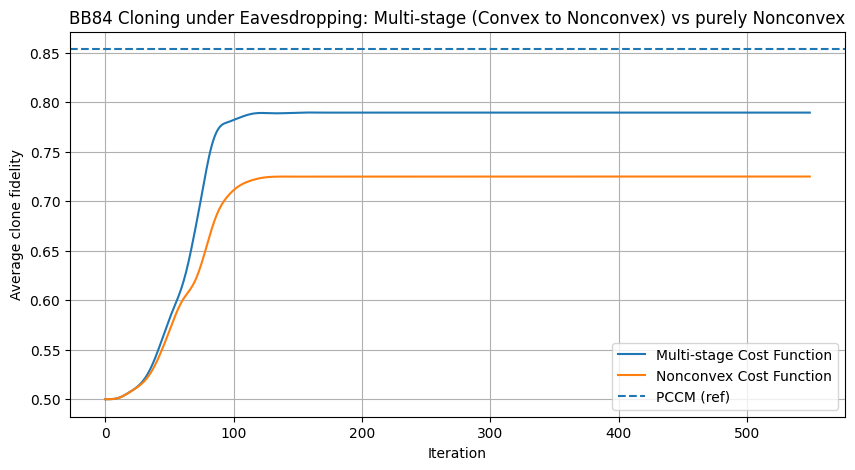

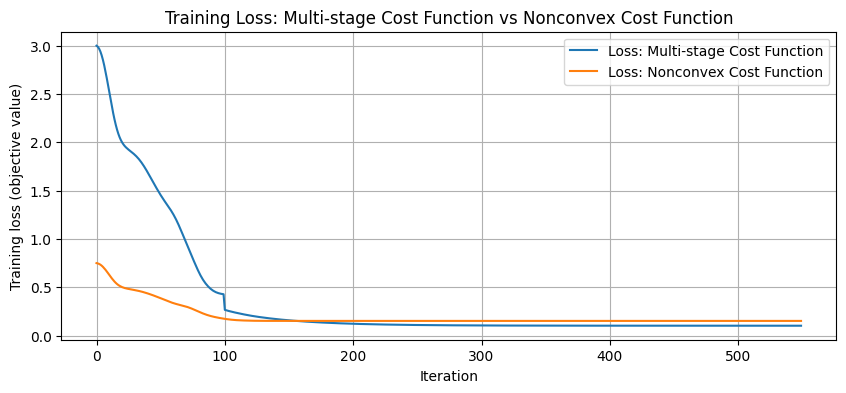

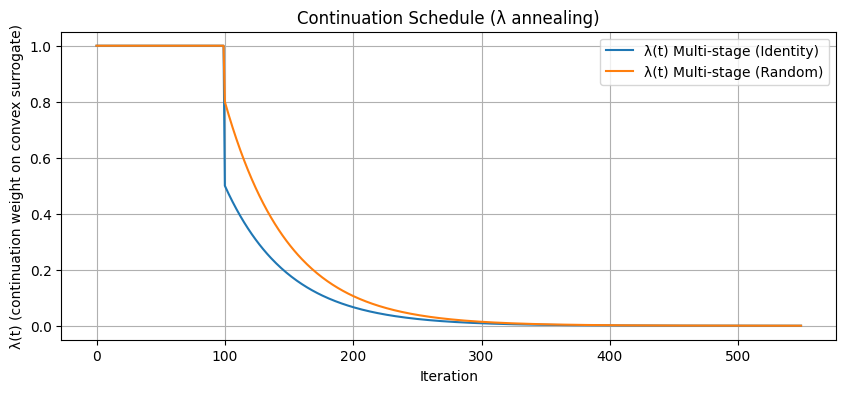

In [7]:
# ============================================================
# BB84 Eavesdropping / Approximate Cloning with PQC-3 (10 Qubits)
# Compare:
#   (1) Multi-stage "convex → nonconvex" continuation (square cost surrogate → square loss target)
#   (2) Direct nonconvex square-loss training
#
# Notes:
# - No HyperNet / QI-ML removed (as requested)
# - Fixes PennyLane queueing: ONE measurement per QNode, no arithmetic inside QNode
# - Fidelity is computed shot-safe via basis overlap trick:
#     F(|ψ>, ρ) = <ψ|ρ|ψ> = P(|0>) after applying adjoint(StatePrep(|ψ>))
#     so F = (1 + <Z>)/2 (for a single qubit after uncompute)
# - Hardware-friendly gates: RX, RZ, CNOT
#
# Author: Francis Boabang
# ============================================================

# !pip install pennylane torch numpy matplotlib pandas

import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
import pennylane as qml

# ----------------------------
# Global setup
# ----------------------------
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device_torch = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using torch device:", device_torch)

# ============================================================
# 1) BB84 states (single-qubit)
# ============================================================

bb84_states  = {
    "0": torch.tensor([1.0, 0.0], dtype=torch.complex64),
    "1": torch.tensor([0.0, 1.0], dtype=torch.complex64),
    "+": torch.tensor([1.0, 1.0], dtype=torch.complex64) / np.sqrt(2),
    "-": torch.tensor([1.0, -1.0], dtype=torch.complex64) / np.sqrt(2),
}
labels = list(bb84_states.keys())






def pccm_fidelity():
    # commonly quoted symmetric phase-covariant cloning value (reference line)
    return 0.8535533905932737

# ============================================================
# 2) System: 10 qubits
#    ALICE holds input state; BOB and EVE are "clones"
#    The rest are ancillas.
# ============================================================

N_QUBITS = 10
ALICE = 0
BOB   = 1
EVE   = 2

# ============================================================
# 3) Devices: analytic / finite shots / noisy
# ============================================================

SHOTS = 1000
dev_analytic = qml.device("default.qubit", wires=N_QUBITS, shots=None)
dev_shots    = qml.device("default.qubit", wires=N_QUBITS, shots=SHOTS)
dev_noisy    = qml.device("default.mixed", wires=N_QUBITS)

# ============================================================
# 4) PQC-3 ansatz (hardware-compatible): RX, RZ, CNOT
# ============================================================

N_LAYERS = 3
N_PARAMS = 2 * N_LAYERS * N_QUBITS

def pqc3_ansatz(weights: torch.Tensor, entangle: bool = True):
    """
    weights shape: (N_PARAMS,)
    """
    idx = 0
    for _ in range(N_LAYERS):
        for q in range(N_QUBITS):
            qml.RX(weights[idx], wires=q); idx += 1
            qml.RZ(weights[idx], wires=q); idx += 1
        if entangle:
            # ring entanglement
            for q in range(N_QUBITS - 1):
                qml.CNOT(wires=[q, q + 1])
            qml.CNOT(wires=[N_QUBITS - 1, 0])

def _prepare(state: torch.Tensor,
             weights: torch.Tensor,
             entangle: bool = True,
             noisy: bool = False,
             p_dep: float = 0.02,
             gamma: float = 0.03):
    """
    Prepare Alice state on wire 0, ancillas start in |0...0>.
    Apply PQC on all qubits. Optionally apply noise channels.
    """
    qml.StatePrep(state, wires=ALICE)
    pqc3_ansatz(weights, entangle=entangle)

    if noisy:
        for q in range(N_QUBITS):
            qml.DepolarizingChannel(p_dep, wires=q)
        for q in range(N_QUBITS):
            qml.AmplitudeDamping(gamma, wires=q)

# ============================================================
# 5) QNodes: return raw <Z> only, fidelity computed outside
#    Fidelity after "uncomputing" the target state:
#      F = (1 + <Z>)/2
# ============================================================

@qml.qnode(dev_analytic, interface="torch", diff_method="backprop")
def z_bob_ideal(state, weights, entangle=True):
    _prepare(state, weights, entangle=entangle, noisy=False)
    qml.adjoint(qml.StatePrep)(state, wires=BOB)
    return qml.expval(qml.PauliZ(BOB))

@qml.qnode(dev_analytic, interface="torch", diff_method="backprop")
def z_eve_ideal(state, weights, entangle=True):
    _prepare(state, weights, entangle=entangle, noisy=False)
    qml.adjoint(qml.StatePrep)(state, wires=EVE)
    return qml.expval(qml.PauliZ(EVE))

@qml.qnode(dev_shots, interface="torch")
def z_bob_shots(state, weights):
    _prepare(state, weights, entangle=True, noisy=False)
    qml.adjoint(qml.StatePrep)(state, wires=BOB)
    return qml.expval(qml.PauliZ(BOB))

@qml.qnode(dev_shots, interface="torch")
def z_eve_shots(state, weights):
    _prepare(state, weights, entangle=True, noisy=False)
    qml.adjoint(qml.StatePrep)(state, wires=EVE)
    return qml.expval(qml.PauliZ(EVE))

@qml.qnode(dev_noisy, interface="torch", diff_method="backprop")
def z_bob_noisy(state, weights, p_dep=0.02, gamma=0.03):
    _prepare(state, weights, entangle=True, noisy=True, p_dep=p_dep, gamma=gamma)
    qml.adjoint(qml.StatePrep)(state, wires=BOB)
    return qml.expval(qml.PauliZ(BOB))

@qml.qnode(dev_noisy, interface="torch", diff_method="backprop")
def z_eve_noisy(state, weights, p_dep=0.02, gamma=0.03):
    _prepare(state, weights, entangle=True, noisy=True, p_dep=p_dep, gamma=gamma)
    qml.adjoint(qml.StatePrep)(state, wires=EVE)
    return qml.expval(qml.PauliZ(EVE))

def z_to_fidelity(Z):
    # After uncompute: P(|0>) = (1 + <Z>)/2
    return 0.5 * (1.0 + Z)

# ============================================================
# 6) Metrics + losses
# ============================================================

def avg_clone_fidelity(weights, entangle=True):
    """Average 1/2(F_B + F_E) over BB84 states."""
    vals = []
    for l in labels:
        st = bb84_states[l]
        ZB = z_bob_ideal(st, weights, entangle=entangle)
        ZE = z_eve_ideal(st, weights, entangle=entangle)
        FB = z_to_fidelity(ZB)
        FE = z_to_fidelity(ZE)
        vals.append(0.5 * (FB + FE))
    return torch.stack(vals).mean()

def nonconvex_square_loss(weights, entangle=True, beta_sym=1.0):
    """
    Target (nonconvex) square loss in *fidelity space*:
      L_nc = (1-FB)^2 + (1-FE)^2 + beta*(FB-FE)^2
    averaged over BB84.
    """
    loss = 0.0
    for l in labels:
        st = bb84_states[l]
        ZB = z_bob_ideal(st, weights, entangle=entangle)
        ZE = z_eve_ideal(st, weights, entangle=entangle)
        FB = z_to_fidelity(ZB)
        FE = z_to_fidelity(ZE)
        loss = loss + (1.0 - FB)**2 + (1.0 - FE)**2
        #+ beta_sym * (FB - FE)**2
    return loss / len(labels)

def convex_square_surrogate(weights, entangle=True):
    """
    "Convex-style" surrogate in *observable (Z) space*:
      L_cx = (1 - <Z_B>)^2 + (1 - <Z_E>)^2
    averaged over BB84.
    This is convex in the measured expectations Z (though still nonconvex in circuit params).
    """
    loss = 0.0
    for l in labels:
        st = bb84_states[l]
        ZB = z_bob_ideal(st, weights, entangle=entangle)
        ZE = z_eve_ideal(st, weights, entangle=entangle)
        loss = loss + (1.0 - ZB)**2 + (1.0 - ZE)**2
    return loss / len(labels)

# ============================================================
# 7) Initializers
# ============================================================

def init_random(scale=0.02):
    w = scale * torch.randn(N_PARAMS)
    w.requires_grad_(True)
    return w

def init_identity_biased(eps=0.03):
    # small angles around 0 ~ "near-identity" start
    scale = eps / np.sqrt(N_QUBITS)
    w = scale * torch.randn(N_PARAMS)
    w.requires_grad_(True)
    return w

# ============================================================
# 8) Training: (A) direct nonconvex vs (B) multi-stage continuation
# ============================================================

def train_direct_nonconvex(w, steps=350, lr=0.02, beta_sym=1.0):
    """
    Directly optimize the nonconvex square loss.
    """
    opt = torch.optim.Adam([w], lr=lr)
    hist_fid = []
    hist_loss = []
    for _ in range(steps):
        opt.zero_grad()
        L = nonconvex_square_loss(w, entangle=True, beta_sym=beta_sym)
        L.backward()
        opt.step()
        with torch.no_grad():
            hist_loss.append(L.item())
            hist_fid.append(avg_clone_fidelity(w).item())
    return hist_fid, hist_loss

def train_multistage_convex_to_nonconvex(
    w,
    stage1_steps=200,
    stage2_steps=350,
    lr=0.02,
    beta_sym=1.0,
    lam0=0.8,
    lam_decay=0.98,
):
    """
    Multi-stage:
      Stage-1: optimize convex surrogate L_cx
      Stage-2: continuation
        L = (1-λ)L_nc + λ L_cx, with λ annealed → 0
    """
    opt = torch.optim.Adam([w], lr=lr)

    hist_fid = []
    hist_loss = []
    lam_hist = []

    # ---- Stage 1: surrogate only ----
    for _ in range(stage1_steps):
        opt.zero_grad()
        L = convex_square_surrogate(w, entangle=True)
        L.backward()
        opt.step()
        with torch.no_grad():
            hist_loss.append(L.item())
            hist_fid.append(avg_clone_fidelity(w).item())
            lam_hist.append(1.0)  # surrogate-only indicator

    # ---- Stage 2: annealed mixture ----
    lam = lam0
    for _ in range(stage2_steps):
        opt.zero_grad()
        Lcx = convex_square_surrogate(w, entangle=True)
        Lnc = nonconvex_square_loss(w, entangle=True, beta_sym=beta_sym)
        L = (1.0 - lam) * Lnc + lam * Lcx
        L.backward()
        opt.step()
        with torch.no_grad():
            hist_loss.append(L.item())
            hist_fid.append(avg_clone_fidelity(w).item())
            lam_hist.append(lam)
        lam = max(0.0, lam * lam_decay)

    return hist_fid, hist_loss, lam_hist

# ============================================================
# 9) Noise evaluation (shots + noisy channels)
# ============================================================

def eval_noise(w, p_dep=0.02, gamma=0.03):
    # shots
    FBs, FEs = [], []
    for l in labels:
        st = bb84_states[l]
        ZB = z_bob_shots(st, w)
        ZE = z_eve_shots(st, w)
        FBs.append(z_to_fidelity(ZB))
        FEs.append(z_to_fidelity(ZE))
    F_shots = 0.5 * (torch.stack(FBs).mean() + torch.stack(FEs).mean()).item()

    # noisy channels
    FBn, FEn = [], []
    for l in labels:
        st = bb84_states[l]
        ZB = z_bob_noisy(st, w, p_dep=p_dep, gamma=gamma)
        ZE = z_eve_noisy(st, w, p_dep=p_dep, gamma=gamma)
        FBn.append(z_to_fidelity(ZB))
        FEn.append(z_to_fidelity(ZE))
    F_noisy = 0.5 * (torch.stack(FBn).mean() + torch.stack(FEn).mean()).item()

    return F_shots, F_noisy

# ============================================================
# 10) Run comparisons
# ============================================================

STAGE1 = 100
STAGE2 = 450
DIRECT = 550  # roughly same budget as multistage total (200+350)

LR = 0.02
BETA_SYM = 1.0

# (1) Multi-stage: identity init
w_ms_id = init_identity_biased()
fid_ms_id, loss_ms_id, lam_ms_id = train_multistage_convex_to_nonconvex(
    w_ms_id, stage1_steps=STAGE1, stage2_steps=STAGE2,
    lr=LR, beta_sym=BETA_SYM, lam0=0.5, lam_decay=0.98
)

# (2) Multi-stage: random init
w_ms_rn = init_random()
fid_ms_rn, loss_ms_rn, lam_ms_rn = train_multistage_convex_to_nonconvex(
    w_ms_rn, stage1_steps=STAGE1, stage2_steps=STAGE2,
    lr=LR, beta_sym=BETA_SYM, lam0=0.8, lam_decay=0.98
)

# (3) Direct nonconvex: identity init
w_dc_id = init_identity_biased()
fid_dc_id, loss_dc_id = train_direct_nonconvex(
    w_dc_id, steps=DIRECT, lr=LR, beta_sym=BETA_SYM
)

# (4) Direct nonconvex: random init
w_dc_rn = init_random()
fid_dc_rn, loss_dc_rn = train_direct_nonconvex(
    w_dc_rn, steps=DIRECT, lr=LR, beta_sym=BETA_SYM
)

# Noise evaluation on final checkpoints
F_ms_id_shots, F_ms_id_noisy = eval_noise(w_ms_id.detach())
F_ms_rn_shots, F_ms_rn_noisy = eval_noise(w_ms_rn.detach())
F_dc_id_shots, F_dc_id_noisy = eval_noise(w_dc_id.detach())
F_dc_rn_shots, F_dc_rn_noisy = eval_noise(w_dc_rn.detach())

# ============================================================
# 11) Summary table
# ============================================================

summary = pd.DataFrame({
    "Run": [
        "Multi-stage (Identity init)",
        "Multi-stage (Random init)",
        "Direct nonconvex (Identity init)",
        "Direct nonconvex (Random init)",
    ],
    "Final Fidelity (ideal)": [
        float(fid_ms_id[-1]), float(fid_ms_rn[-1]), float(fid_dc_id[-1]), float(fid_dc_rn[-1])
    ],
    f"Fidelity (shots={SHOTS})": [
        F_ms_id_shots, F_ms_rn_shots, F_dc_id_shots, F_dc_rn_shots
    ],
    "Fidelity (noisy)": [
        F_ms_id_noisy, F_ms_rn_noisy, F_dc_id_noisy, F_dc_rn_noisy
    ],
})

print("\n=== BB84 EAVESDROPPING / CLONING COMPARISON ===")
print(summary.to_string(index=False))
print("\nReference PCCM fidelity:", pccm_fidelity())

# ============================================================
# 12) Publication-ready plots
# ============================================================

plt.figure(figsize=(10, 5))
plt.plot(fid_ms_id, label="Multi-stage Cost Function")
#plt.plot(fid_ms_rn, label="Multi-stage (Random init)")
plt.plot(fid_dc_id, label="Nonconvex Cost Function")
#plt.plot(fid_dc_rn, label="Direct nonconvex (Random init)")
plt.axhline(pccm_fidelity(), linestyle="--", label="PCCM (ref)")
plt.xlabel("Iteration")
plt.ylabel("Average clone fidelity")
plt.title("BB84 Cloning under Eavesdropping: Multi-stage (Convex to Nonconvex) vs purely Nonconvex")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(loss_ms_id, label="Loss: Multi-stage Cost Function")
plt.plot(loss_dc_id, label="Loss: Nonconvex Cost Function")
plt.xlabel("Iteration")
plt.ylabel("Training loss (objective value)")
plt.title("Training Loss: Multi-stage Cost Function vs Nonconvex Cost Function")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(lam_ms_id, label="λ(t) Multi-stage (Identity)")
plt.plot(lam_ms_rn, label="λ(t) Multi-stage (Random)")
plt.xlabel("Iteration")
plt.ylabel("λ(t) (continuation weight on convex surrogate)")
plt.title("Continuation Schedule (λ annealing)")
plt.grid(True)
plt.legend()
plt.show()


In [ ]:
pip install pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.1/57.1 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 91.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 934.3/934.3 kB 46.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 68.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 81.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 107.6 MB/s eta 0:00:00


In [ ]:
# REAL  DATASETS

In [6]:
# ============================================================
# PQC-3 Random vs Convex-Initialized Benchmark
# (Algorithm 1: Two-Stage Optimization for Barren Plateaus)
# PennyLane + PyTorch
#
# Models:
#   - PQC-3 (Random initialization, standard regression)
#   - PQC-3 (Convex-initialized + Nonconvex refinement, Algorithm-1)
#   - Classical MLP baseline (He/Xavier)
#
# Extras:
#   - Learning curves (Test MSE)
#   - Shot-noise simulation (finite shots)
#   - Noisy channels (Depolarizing + Amplitude Damping)
#   - Barren plateau diagnostics (Convex-init gradient norm history)
#   - Hardware-compatible gates (IBM-style: RX, RZ, CNOT)
#   - Auto-generated CSV + LaTeX table and PDF plots
#
# Author: Boabang Francis (with ChatGPT scaffold)
# ============================================================

# 0. INSTALLS (uncomment in Colab)
# !pip install pennylane pennylane-lightning pennylane-qchem
# !pip install torch torchvision matplotlib pandas scikit-learn

import math
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import pandas as pd
import pennylane as qml

from sklearn.datasets import load_wine, load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torchvision import datasets, transforms

# ------------------------------------------------------------
# Global setup
# ------------------------------------------------------------
np.random.seed(42)
torch.manual_seed(42)

device_torch = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using torch device:", device_torch)

# Directory for saving figures / tables
out_dir = Path("./qml_outputs")
out_dir.mkdir(exist_ok=True)

# ============================================================
# DATASET CHOICE
#   options: "toy", "wine", "optdigits", "mnist"
# ============================================================
DATASET = "optdigits"       # "toy" | "wine" | "optdigits" | "mnist"

# ============================================================
# 1. Dataset Loader (Toy / Wine / MNIST / Optdigits)
#    All returned as: X ∈ R^{N×D}, y ∈ R^{N×1}
#    Labels for classification datasets are rescaled to [-1, 1]
#    to match PQC output range for regression-style MSE.
# ============================================================

def make_toy_regression_dataset(n_samples=256, x_range=(-math.pi, math.pi)):
    xs = np.random.uniform(x_range[0], x_range[1], size=(n_samples, 1))
    ys = np.sin(2 * xs) + 0.5 * np.cos(xs)   # nonlinear target
    xs = xs.astype(np.float32)
    ys = ys.astype(np.float32)
    return xs, ys

def make_tinymnist(subsample=2000, test_subsample=500, downscale_to=None):
    """
    TinyMNIST loader:
    - subsample: number of train samples
    - test_subsample: number of test samples
    - downscale_to: None | 14 | 8 (image resolution)
    """

    transform_list = [transforms.ToTensor()]   # (1, H, W) → [0,1]

    if downscale_to is not None:
        transform_list.append(
            transforms.Resize((downscale_to, downscale_to))
        )

    transform = transforms.Compose(transform_list)

    train_ds = datasets.MNIST("./data", train=True, download=True, transform=transform)
    test_ds  = datasets.MNIST("./data", train=False, download=True, transform=transform)

    # ---- Subsample to keep PQC simulation lightweight ----
    idx_train = np.random.choice(len(train_ds), size=subsample, replace=False)
    idx_test  = np.random.choice(len(test_ds),  size=test_subsample, replace=False)

    X_train = train_ds.data[idx_train].numpy().astype(np.float32)
    y_train_raw = train_ds.targets[idx_train].numpy().astype(np.int64)

    X_test = test_ds.data[idx_test].numpy().astype(np.float32)
    y_test_raw = test_ds.targets[idx_test].numpy().astype(np.int64)

    # ---- Normalize ----
    X_train /= 255.0
    X_test  /= 255.0

    # ---- Flatten ----
    H = downscale_to if downscale_to else 28
    X_train = X_train.reshape(-1, H * H)
    X_test  = X_test.reshape(-1, H * H)

    y_train = normalize_labels_to_minus1_1(y_train_raw)
    y_test  = normalize_labels_to_minus1_1(y_test_raw)

    return X_train, y_train, X_test, y_test, H * H

def normalize_labels_to_minus1_1(y):
    """Map integer labels or continuous y to [-1, 1] for regression."""
    y = y.astype(np.float32).reshape(-1, 1)
    y_min, y_max = y.min(), y.max()
    if y_max == y_min:
        return np.zeros_like(y, dtype=np.float32)
    return 2.0 * (y - y_min) / (y_max - y_min) - 1.0


def make_dataset(name="toy", test_size=0.33, random_state=42):
    name = name.lower()

    if name == "toy":
        X_train, y_train = make_toy_regression_dataset(256)
        X_test,  y_test  = make_toy_regression_dataset(128)
        input_dim = 1
        return X_train, y_train, X_test, y_test, input_dim

   # elif name == "tinymnist":
    # Example: 2000 training, 500 test, downscale to 14×14
    #    return make_tinymnist(subsample=2000, test_subsample=500, downscale_to=14)


    elif name == "wine":
        data = load_wine()
        X = data.data.astype(np.float32)     # (N, 13)
        y = data.target.astype(np.int64)     # 0,1,2

        scaler = StandardScaler()
        X = scaler.fit_transform(X).astype(np.float32)

        y_reg = normalize_labels_to_minus1_1(y)

        X_train, X_test, y_train, y_test = train_test_split(
            X, y_reg, test_size=test_size, random_state=random_state, stratify=y
        )
        input_dim = X.shape[1]
        return X_train, y_train, X_test, y_test, input_dim

    elif name == "optdigits":
        digits = load_digits()
        X = digits.data.astype(np.float32)   # (N, 64)
        y = digits.target.astype(np.int64)   # 0–9

        scaler = StandardScaler()
        X = scaler.fit_transform(X).astype(np.float32)

        y_reg = normalize_labels_to_minus1_1(y)

        X_train, X_test, y_train, y_test = train_test_split(
            X, y_reg, test_size=test_size, random_state=random_state, stratify=y
        )
        input_dim = X.shape[1]
        return X_train, y_train, X_test, y_test, input_dim

    elif name == "mnist":
        # Use torchvision MNIST, flattened to 784
        transform = transforms.ToTensor()  # [0,1], shape (1,28,28)

        train_dataset = datasets.MNIST(
            root="./data", train=True, download=True, transform=transform
        )
        test_dataset = datasets.MNIST(
            root="./data", train=False, download=True, transform=transform
        )

        X_train = train_dataset.data.numpy().astype(np.float32).reshape(-1, 28 * 28)
        y_train_raw = train_dataset.targets.numpy().astype(np.int64)

        X_test = test_dataset.data.numpy().astype(np.float32).reshape(-1, 28 * 28)
        y_test_raw = test_dataset.targets.numpy().astype(np.int64)

        # Normalize pixels to [0,1]
        X_train /= 255.0
        X_test  /= 255.0

        # Optional subsampling to keep quantum simulations lighter
        # idx_train = np.random.choice(len(X_train), size=5000, replace=False)
        # idx_test  = np.random.choice(len(X_test), size=1000, replace=False)
        # X_train, y_train_raw = X_train[idx_train], y_train_raw[idx_train]
        # X_test,  y_test_raw  = X_test[idx_test],  y_test_raw[idx_test]

        y_train = normalize_labels_to_minus1_1(y_train_raw)
        y_test  = normalize_labels_to_minus1_1(y_test_raw)

        input_dim = X_train.shape[1]
        return X_train, y_train, X_test, y_test, input_dim

    else:
        raise ValueError(f"Unknown DATASET = {name}")


# ---- Create tensors + loaders ----
X_train, y_train, X_test, y_test, INPUT_DIM = make_dataset(DATASET)

X_train_t = torch.from_numpy(X_train).to(device_torch)
y_train_t = torch.from_numpy(y_train).to(device_torch)
X_test_t  = torch.from_numpy(X_test).to(device_torch)
y_test_t  = torch.from_numpy(y_test).to(device_torch)

train_ds = TensorDataset(X_train_t, y_train_t)
test_ds  = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=64, shuffle=False)

print(f"Dataset: {DATASET}")
print("Train shape:", X_train_t.shape, y_train_t.shape)
print("Test  shape:", X_test_t.shape,  y_test_t.shape)

# ============================================================
# 2. Quantum Devices (Analytic, Shot-based, Noisy)
# ============================================================

N_QUBITS = 10

# Ideal analytic device (no noise, infinite shots)
dev_analytic = qml.device("default.qubit", wires=N_QUBITS, shots=None)

# Shot-based device (shot noise)
SHOTS = 1000
dev_shots = qml.device("default.qubit", wires=N_QUBITS, shots=SHOTS)

# Noisy mixed-state device for depolarizing + amplitude damping
dev_noisy = qml.device("default.mixed", wires=N_QUBITS)

# ============================================================
# 3. Classical-to-Quantum Feature Encoding
#    Map x ∈ R^D → R^{N_QUBITS} and use AngleEmbedding.
# ============================================================

def encode_x_to_features(x_vec, n_qubits=N_QUBITS):
    """
    Map input x (scalar or vector) → feature vector R^{n_qubits}.

    - If x has 1 dim (toy case): use [x, x^2, sin(x), cos(x), 0, ...].
    - If x has >1 dims (wine / mnist / optdigits): take the first
      n_qubits components, padding with zeros if needed.
    """
    # Ensure 1D tensor
    if x_vec.dim() == 0:
        x_vec = x_vec.unsqueeze(0)

    # Toy 1D case
    if x_vec.numel() == 1:
        x = x_vec[0]
        feats = [x, x**2, torch.sin(x), torch.cos(x)]
        feats = feats[:n_qubits]
        if len(feats) < n_qubits:
            pad = [torch.zeros((), dtype=x.dtype, device=x.device)
                   for _ in range(n_qubits - len(feats))]
            feats = feats + pad
        return torch.stack(feats)

    # Multi-dimensional input
    if x_vec.numel() >= n_qubits:
        return x_vec[:n_qubits]
    else:
        pad = torch.zeros(n_qubits - x_vec.numel(),
                          dtype=x_vec.dtype, device=x_vec.device)
        return torch.cat([x_vec, pad], dim=0)

# ============================================================
# 4. Hardware-Compatible PQC Ansätze (IBM-style)
#    Gates: RX, RZ, CNOT (all native on IBM).
# ============================================================

def pqc3_ansatz(features, weights):
    """
    PQC-3 (deeper) ansatz.
    features: (n_qubits,)
    weights:  (n_layers, n_qubits, 2)
    """
    qml.AngleEmbedding(features, wires=range(N_QUBITS), rotation="Y")
    n_layers = weights.shape[0]

    for layer in range(n_layers):
        for i in range(N_QUBITS):
            qml.RX(weights[layer, i, 0], wires=i)
            qml.RZ(weights[layer, i, 1], wires=i)
        for i in range(N_QUBITS - 1):
            qml.CNOT(wires=[i, i + 1])
        qml.CNOT(wires=[N_QUBITS - 1, 0])

# ============================================================
# 5. QNodes (Analytic / Shot-based / Noisy)
# ============================================================

@qml.qnode(dev_analytic, interface="torch")
def pqc3_qnode(x, weights):
    feats = encode_x_to_features(x)
    pqc3_ansatz(feats, weights)
    return qml.expval(qml.PauliZ(0))


@qml.qnode(dev_shots, interface="torch")
def pqc3_qnode_shots(x, weights):
    feats = encode_x_to_features(x)
    pqc3_ansatz(feats, weights)
    return qml.expval(qml.PauliZ(0))


@qml.qnode(dev_noisy, interface="torch")
def pqc3_qnode_noisy(x, weights, p_dep=0.02, gamma_amp=0.03):
    feats = encode_x_to_features(x)
    pqc3_ansatz(feats, weights)

    # Depolarizing noise (each qubit)
    for i in range(N_QUBITS):
        qml.DepolarizingChannel(p_dep, wires=i)

    # Amplitude damping (each qubit)
    for i in range(N_QUBITS):
        qml.AmplitudeDamping(gamma_amp, wires=i)

    return qml.expval(qml.PauliZ(0))

# ============================================================
# 6. Torch Wrappers: PQC-3
# ============================================================

class PQC3Model(nn.Module):
    def __init__(self, n_qubits=N_QUBITS, n_layers=3):
        super().__init__()
        self.n_qubits = n_qubits
        self.n_layers = n_layers
        self.weights = nn.Parameter(0.01 * torch.randn(n_layers, n_qubits, 2))

    def forward(self, x_batch):
        out = []
        for x in x_batch:
            out.append(pqc3_qnode(x, self.weights))
        return torch.stack(out).unsqueeze(-1)  # (batch, 1)

# ============================================================
# 7. Classical MLP Baseline
# ============================================================

class MLPBaseline(nn.Module):
    def __init__(self, in_dim=1, hidden_dim=32, out_dim=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, out_dim),
        )

    def forward(self, x):
        # x: (batch, D)
        return self.net(x)

# ============================================================
# 8. Training & Evaluation Utilities
# ============================================================

def train_epoch(model, loader, optimizer, l2_lambda=0.0):
    model.train()
    total_loss = 0.0
    total_n = 0

    for xb, yb in loader:
        xb = xb.to(device_torch)
        yb = yb.to(device_torch)

        optimizer.zero_grad()
        preds = model(xb)  # (batch, 1)
        mse = torch.mean((preds - yb) ** 2)

        l2_reg = torch.tensor(0.0, device=device_torch)
        if l2_lambda > 0:
            for p in model.parameters():
                l2_reg = l2_reg + torch.sum(p ** 2)

        loss = mse + l2_lambda * l2_reg
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb.size(0)
        total_n += xb.size(0)

    return total_loss / total_n


def eval_mse(model, loader):
    model.eval()
    total_mse = 0.0
    total_n = 0
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device_torch)
            yb = yb.to(device_torch)
            preds = model(xb)
            mse = torch.mean((preds - yb) ** 2)
            total_mse += mse.item() * xb.size(0)
            total_n += xb.size(0)
    return total_mse / total_n


def eval_shot_mse(pqc3_model, loader):
    """
    Evaluate PQC-3 under finite shots (shot noise).
    """
    pqc3_model.eval()
    total_mse, total_n = 0.0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device_torch), yb.to(device_torch)
            preds = []
            for x in xb:
                preds.append(pqc3_qnode_shots(x, pqc3_model.weights))
            preds = torch.stack(preds).unsqueeze(-1)
            mse = torch.mean((preds - yb) ** 2)
            total_mse += mse.item() * xb.size(0)
            total_n += xb.size(0)
    return total_mse / total_n


def eval_noisy_mse(pqc3_model, loader, p_dep=0.02, gamma_amp=0.03):
    """
    Evaluate PQC-3 under depolarizing + amplitude damping noise.
    """
    pqc3_model.eval()
    total_mse, total_n = 0.0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device_torch), yb.to(device_torch)
            preds = []
            for x in xb:
                preds.append(
                    pqc3_qnode_noisy(
                        x, pqc3_model.weights,
                        p_dep=p_dep, gamma_amp=gamma_amp
                    )
                )
            preds = torch.stack(preds).unsqueeze(-1)
            mse = torch.mean((preds - yb) ** 2)
            total_mse += mse.item() * xb.size(0)
            total_n += xb.size(0)
    return total_mse / total_n

# ============================================================
# 9. Helpers for Algorithm-1: Convex Init + Oscillatory Reg.
# ============================================================

def grad_norm_sq_per_dim(model):
    """
    ||∇θ L||^2 / dim(θ)  (assumes backward() has been called)
    """
    total = 0.0
    dim = 0
    for p in model.parameters():
        if p.grad is not None:
            total += (p.grad ** 2).sum()
            dim += p.numel()
    if dim == 0:
        return 0.0
    return (total / dim).item()


def oscillatory_regularizer(model, omega=5.0):
    """
    R_osc(θ) = E_j[ sin(ω θ_j) ]  (simple oscillatory regularization).
    """
    thetas = []
    for p in model.parameters():
        thetas.append(p.view(-1))
    if len(thetas) == 0:
        return torch.tensor(0.0, device=device_torch)
    theta_vec = torch.cat(thetas)
    return torch.sin(omega * theta_vec).mean()


def convex_init_pqc3_regression(
    model,
    loader,
    tau_g=1e-20,
    max_epochs=50,
    lr=0.02
):
    """
    Algorithm-1 Stage-1: Convex Initialization.
        L_convex(θ) = E[ f_θ(x)^2 ]
    Used to escape barren plateaus via a convex-in-output surrogate
    and a gradient-norm threshold τ_g.
    """
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    grad_hist = []

    for ep in range(1, max_epochs + 1):
        model.train()
        total_g2 = 0.0
        n_batches = 0

        for xb, _ in loader:
            xb = xb.to(device_torch)

            opt.zero_grad()
            preds = model(xb)

            # Strictly convex quadratic surrogate in outputs
            L_convex = torch.mean(preds ** 2)
            L_convex.backward()

            g2 = grad_norm_sq_per_dim(model)
            grad_hist.append(g2)
            total_g2 += g2
            n_batches += 1

            opt.step()

        mean_g2 = total_g2 / max(1, n_batches)
        print(f"[Convex Init] Epoch {ep:2d} | grad²/dim={mean_g2:.3e}")

        # Algorithm 1: stop when gradient strength is above τ_g
        if mean_g2 >= tau_g:
            print("✅ Convex-init exit: gradient threshold reached.")
            break

    return grad_hist

# ============================================================
# 10. Learning-Curve Containers
# ============================================================

curve = {
    "pqc3_rand_train": [], "pqc3_rand_test": [],
    "pqc3_conv_train": [], "pqc3_conv_test": [],
    "mlp_train": [],       "mlp_test": []
}

convex_grad_history = []  # for barren plateau diagnostics

# ============================================================
# 11. PQC-3 (Random Initialization, Standard Regression)
# ============================================================

pqc3_rand = PQC3Model(n_qubits=N_QUBITS, n_layers=3).to(device_torch)

with torch.no_grad():
    pqc3_rand.weights[:] = 0.01 * torch.randn_like(pqc3_rand.weights)

optimizer3_rand = torch.optim.Adam(pqc3_rand.parameters(), lr=0.01)
l2_lambda_pqc3_rand = 5e-4
EPOCHS_PQC3_RAND = 60

print("=== Training PQC-3 (Random Init) ===")
for epoch in range(1, EPOCHS_PQC3_RAND + 1):
    _ = train_epoch(
        pqc3_rand, train_loader, optimizer3_rand,
        l2_lambda=l2_lambda_pqc3_rand
    )
    train_mse = eval_mse(pqc3_rand, train_loader)
    test_mse  = eval_mse(pqc3_rand, test_loader)

    curve["pqc3_rand_train"].append(train_mse)
    curve["pqc3_rand_test"].append(test_mse)

    if epoch % 10 == 0 or epoch == 1:
        print(f"[PQC-3 Rand] Epoch {epoch:3d} | "
              f"train_mse={train_mse:.5f} | test_mse={test_mse:.5f}")

pqc3_rand_train_mse_final = eval_mse(pqc3_rand, train_loader)
pqc3_rand_test_mse_final  = eval_mse(pqc3_rand, test_loader)
n_params_pqc3 = sum(p.numel() for p in pqc3_rand.parameters())

# ============================================================
# 12. PQC-3 (Algorithm-1: Convex Init + Nonconvex Refinement)
# ============================================================

pqc3_conv = PQC3Model(n_qubits=N_QUBITS, n_layers=3).to(device_torch)

with torch.no_grad():
    pqc3_conv.weights[:] = 0.01 * torch.randn_like(pqc3_conv.weights)

print("\n=== Convex Initialization of PQC-3 (Algorithm-1 Stage-1) ===")
convex_grad_history = convex_init_pqc3_regression(
    pqc3_conv,
    train_loader,
    tau_g=1e-20,
    max_epochs=50,
    lr=0.02
)

# Stage-2: Nonconvex refinement with L_refine
optimizer3_conv = torch.optim.Adam(pqc3_conv.parameters(), lr=0.01)
l2_lambda_pqc3_conv = 5e-7
EPOCHS_PQC3_CONV = 60

# Continuation / annealing parameters (Algorithm-1)
lambda0, beta0 = 0.5, 0.1
lambda_, beta = lambda0, beta0
omega_osc = 5.0  # frequency for R_osc (if used)

print("\n=== Training PQC-3 (Convex-Init + Nonconvex Refinement) ===")
for epoch in range(1, EPOCHS_PQC3_CONV + 1):
    pqc3_conv.train()
    for xb, yb in train_loader:
        xb = xb.to(device_torch)
        yb = yb.to(device_torch)

        optimizer3_conv.zero_grad()
        preds = pqc3_conv(xb)

        # Task loss (nonconvex objective proxy: regression MSE)
        task_loss = torch.mean((preds - yb) ** 2)

        # Convex surrogate term (as in Stage-1)
        L_convex = torch.mean(preds ** 2)

        # Oscillatory regularization term R_osc(θ) (can be included if desired)
        # R_osc = oscillatory_regularizer(pqc3_conv, omega=omega_osc)

        # Total refinement loss (Algorithm-1 Stage-2)
        # With oscillatory reg:
        # total_loss = (1.0 - lambda_) * task_loss + lambda_ * L_convex + beta * R_osc
        # Without oscillatory reg (as in current experiments):
        total_loss = (1.0 - lambda_) * task_loss + lambda_ * L_convex

        # Optional L2 on weights
        if l2_lambda_pqc3_conv > 0:
            l2_reg = torch.tensor(0.0, device=device_torch)
            for p in pqc3_conv.parameters():
                l2_reg = l2_reg + torch.sum(p ** 2)
            total_loss = total_loss + l2_lambda_pqc3_conv * l2_reg

        total_loss.backward()
        optimizer3_conv.step()

    # Anneal continuation parameters (Algorithm-1)
    lambda_ = max(0.0, 0.98 * lambda_)
    beta = 0.99 * beta

    # Track pure task MSE for learning curves
    train_mse = eval_mse(pqc3_conv, train_loader)
    test_mse  = eval_mse(pqc3_conv, test_loader)

    curve["pqc3_conv_train"].append(train_mse)
    curve["pqc3_conv_test"].append(test_mse)

    if epoch % 10 == 0 or epoch == 1:
        print(f"[PQC-3 Alg1] Epoch {epoch:3d} | "
              f"train_mse={train_mse:.5f} | test_mse={test_mse:.5f} "
              f"| lambda={lambda_:.3f} | beta={beta:.3f}")

pqc3_conv_train_mse_final = eval_mse(pqc3_conv, train_loader)
pqc3_conv_test_mse_final  = eval_mse(pqc3_conv, test_loader)

# ============================================================
# 13. Classical MLP Baseline Training
# ============================================================

mlp_model = MLPBaseline(in_dim=INPUT_DIM).to(device_torch)
opt_mlp = torch.optim.Adam(mlp_model.parameters(), lr=0.01)
EPOCHS_MLP = 60

print("\n=== Training Classical MLP Baseline ===")
for epoch in range(1, EPOCHS_MLP + 1):
    _ = train_epoch(mlp_model, train_loader, opt_mlp, l2_lambda=1e-4)
    train_mse = eval_mse(mlp_model, train_loader)
    test_mse  = eval_mse(mlp_model, test_loader)

    curve["mlp_train"].append(train_mse)
    curve["mlp_test"].append(test_mse)

    if epoch % 10 == 0 or epoch == 1:
        print(f"[MLP] Epoch {epoch:3d} | train_mse={train_mse:.5f} "
              f"| test_mse={test_mse:.5f}")

mlp_train_mse_final = eval_mse(mlp_model, train_loader)
mlp_test_mse_final  = eval_mse(mlp_model, test_loader)
n_params_mlp = sum(p.numel() for p in mlp_model.parameters())

# ============================================================
# 14. Shot-Noise & Hardware Noise Evaluation (PQC-3 Rand vs Convex)
# ============================================================

print("\n=== Shot-Noise Evaluation (Test MSE) ===")
print("PQC-3 Rand   (shots):", eval_shot_mse(pqc3_rand, test_loader))
print("PQC-3 Convex (shots):", eval_shot_mse(pqc3_conv, test_loader))

print("\n=== Noisy Channel Evaluation (Test MSE) ===")
print("PQC-3 Rand   (noisy):", eval_noisy_mse(pqc3_rand, test_loader))
print("PQC-3 Convex (noisy):", eval_noisy_mse(pqc3_conv, test_loader))

# ============================================================
# 15. Results Table + LaTeX Export
# ============================================================

results = pd.DataFrame({
    "Model": [
        "PQC-3 (Random Init)",
        "PQC-3 (Alg.1: Convex+Refine)",
        "Classical MLP"
    ],
    "Train MSE": [
        pqc3_rand_train_mse_final,
        pqc3_conv_train_mse_final,
        mlp_train_mse_final
    ],
    "Test MSE": [
        pqc3_rand_test_mse_final,
        pqc3_conv_test_mse_final,
        mlp_test_mse_final
    ],
    "Parameters": [
        n_params_pqc3,
        n_params_pqc3,
        n_params_mlp
    ]
})

print("\n=== COMPARISON TABLE ===")
print(results)

results.to_csv(out_dir / "pqc3_comparison.csv", index=False)

latex_table = results.to_latex(index=False, float_format="%.4f")
with open(out_dir / "pqc3_comparison.tex", "w") as f:
    f.write(latex_table)

print("\nLaTeX table saved to:", out_dir / "pqc3_comparison.tex")

# ============================================================
# 16. Plots: Learning Curves + Function Fits + Grad Norm
# ============================================================

def plot_learning_curves(curve_dict, savepath=None):
    plt.figure(figsize=(9, 6))
    plt.plot(curve_dict["pqc3_rand_test"],   label="PQC-3 (Random)", linewidth=2)
    plt.plot(curve_dict["pqc3_conv_test"],   label="PQC-3 (Alg.1 Convex+Refine)", linewidth=2)
    plt.plot(curve_dict["mlp_test"],         label="Classical MLP", linewidth=2)
    plt.xlabel("Epoch")
    plt.ylabel("Test MSE")
    plt.yscale("log")
    plt.title(f"Learning Curves (Test MSE, log-scale) — {DATASET}")
    plt.legend()
    plt.grid(True)
    if savepath is not None:
        plt.savefig(savepath, bbox_inches="tight", dpi=300)
    plt.show()


def plot_model_fit_three(model1, model2, model3,
                         labels=("PQC-3 Random", "PQC-3 Alg.1", "MLP"),
                         x_range=(-math.pi, math.pi), n_points=200,
                         savepath=None):

    model1.eval(); model2.eval(); model3.eval()

    xs = torch.linspace(x_range[0], x_range[1], n_points).unsqueeze(-1).to(device_torch)
    with torch.no_grad():
        y_true = torch.sin(2 * xs) + 0.5 * torch.cos(xs)
        y1 = model1(xs)
        y2 = model2(xs)
        y3 = model3(xs)

    xs_np = xs.cpu().numpy().flatten()
    y_true_np = y_true.cpu().numpy().flatten()
    y1_np = y1.cpu().numpy().flatten()
    y2_np = y2.cpu().numpy().flatten()
    y3_np = y3.cpu().numpy().flatten()

    plt.figure(figsize=(9, 6))
    plt.plot(xs_np, y_true_np, label="True f(x)", linewidth=3)
    plt.scatter(xs_np, y1_np, s=12, alpha=0.7, label=labels[0])
    plt.scatter(xs_np, y2_np, s=12, alpha=0.7, label=labels[1])
    plt.scatter(xs_np, y3_np, s=12, alpha=0.7, label=labels[2])
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Function Approximation: PQC-3 vs MLP")
    plt.legend()
    plt.grid(True)
    if savepath is not None:
        plt.savefig(savepath, bbox_inches="tight", dpi=300)
    plt.show()


def plot_convex_grad_history(grad_hist, savepath=None):
    if len(grad_hist) == 0:
        return
    plt.figure(figsize=(7, 5))
    plt.plot(grad_hist, marker="o", linewidth=1)
    plt.xlabel("Convex-Init Step")
    plt.ylabel(r"$\|\nabla_\theta L_{\mathrm{convex}}\|^2 / \dim(\theta)$")
    plt.yscale("log")
    plt.title("Barren Plateau Diagnostic: Gradient Norm (Convex Init)")
    plt.grid(True)
    if savepath is not None:
        plt.savefig(savepath, bbox_inches="tight", dpi=300)
    plt.show()


# Generate and save plots
lc_path   = out_dir / f"learning_curves_pqc3_{DATASET}.pdf"
fit_path  = out_dir / f"function_fit_pqc3_{DATASET}.pdf"
grad_path = out_dir / f"convex_init_grad_norm_{DATASET}.pdf"

plot_learning_curves(curve, savepath=lc_path)

# Only do the 1D function-approximation plot for the toy dataset
if DATASET.lower() == "toy":
    plot_model_fit_three(pqc3_rand, pqc3_conv, mlp_model, savepath=fit_path)

plot_convex_grad_history(convex_grad_history, savepath=grad_path)

print("\nFigures saved to:")
print("  -", lc_path)
if DATASET.lower() == "toy":
    print("  -", fit_path)
print("  -", grad_path)


Using torch device: cpu
Dataset: optdigits
Train shape: torch.Size([1203, 64]) torch.Size([1203, 1])
Test  shape: torch.Size([594, 64]) torch.Size([594, 1])
=== Training PQC-3 (Random Init) ===


/usr/local/lib/python3.12/dist-packages/pennylane/devices/device_api.py:193: PennyLaneDeprecationWarning: Setting shots on device is deprecated. Please use the `set_shots` transform on the respective QNode instead.
  warnings.warn(


[PQC-3 Rand] Epoch   1 | train_mse=0.40683 | test_mse=0.40615
[PQC-3 Rand] Epoch  10 | train_mse=0.37956 | test_mse=0.38393
[PQC-3 Rand] Epoch  20 | train_mse=0.37432 | test_mse=0.38356
[PQC-3 Rand] Epoch  30 | train_mse=0.37283 | test_mse=0.38280
[PQC-3 Rand] Epoch  40 | train_mse=0.37155 | test_mse=0.38096
[PQC-3 Rand] Epoch  50 | train_mse=0.36973 | test_mse=0.37536
[PQC-3 Rand] Epoch  60 | train_mse=0.36896 | test_mse=0.37333

=== Convex Initialization of PQC-3 (Algorithm-1 Stage-1) ===


ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipython-input-3270861675.py", line 596, in <cell line: 0>
    convex_grad_history = convex_init_pqc3_regression(
                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipython-input-3270861675.py", line 518, in convex_init_pqc3_regression
    preds = model(xb)
            ^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py", line 1775, in _wrapped_call_impl
    return self._call_impl(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py", line 1786, in _call_impl
    return forward_call(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipython-input-3270861675.py", line 350, in forward
    out.append(pqc3_qnode(x, self.weights))
      

TypeError: object of type 'NoneType' has no len()

In [ ]:
pip install pennyLane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.1/57.1 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 102.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 934.3/934.3 kB 47.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 53.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 52.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 74.2 MB/s eta 0:00:00
